In [1]:
## Load Packages
import numpy as np
import pandas as pd
# plots
import matplotlib.pyplot as plt
import seaborn as sns
# to scale data
from sklearn.preprocessing import StandardScaler
# for grid search
from sklearn.model_selection import GridSearchCV
# to split in test and train
from sklearn.model_selection import train_test_split
# models
from sklearn.linear_model import Lasso, Ridge, LinearRegression
# metric
from sklearn.metrics import mean_squared_error
# to compute polynomial interactions
from sklearn.preprocessing import PolynomialFeatures

# Whether to include interaction features and squares into the regression
# Note: if you include them Grid Search on Lasso will take around 40mins with 12 workers, and xgboost MUCH more.
# The outcome is that OLS deteriorates a lot, while others stay more or less stable...
InlcudeInteraction = False

In [2]:
# Read data
data = pd.read_csv('train.csv')

# Show all Columns in DF
pd.set_option('display.max_rows', data.shape[0])
pd.set_option('display.max_columns', data.shape[1])

# see data
data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [3]:
## Cleaning and preparing data

# Train df - exclude missing data
# Columns
total = data.isnull().sum().sort_values(ascending=False)
percent = (data.isnull().sum()/data.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
data = data.drop((missing_data[missing_data['Total'] > 1]).index,1) # drop if more than 1 missing
# rows - Electrical only one missing
data = data.drop(data.loc[data['Electrical'].isnull()].index)

# Delete outliers - 2% in terms of area
bottom = np.percentile(data['GrLivArea'], 1)
top = np.percentile(data['GrLivArea'], 99)
data = data.drop(data[data['GrLivArea'] <= bottom].index)
data = data.drop(data[data['GrLivArea'] >= top].index)

# Logarithmic transformation in some variables
data['SalePrice'] = np.log(data['SalePrice'])
data['GrLivArea'] = np.log(data['GrLivArea'])

# Create column for new variable
data['HasBsmt'] = pd.Series(len(data['TotalBsmtSF']), index=data.index)
data['HasBsmt'] = 0 
data.loc[data['TotalBsmtSF'] > 0,'HasBsmt'] = 1

# Transform data
data.loc[data['HasBsmt']==1,'TotalBsmtSF'] = np.log(data['TotalBsmtSF'])

# Transform qualitative features into quantitative features (i.e.: dummies)
data = pd.get_dummies(data)

# drop id
data = data.drop(["Id"], axis = 1)

# Separate price column from train table
y = data['SalePrice']
x = data.drop(["SalePrice"], axis = 1)

# Features with no value are filled with the mean
mean = x.mean().astype(np.int32)
x.fillna( mean , inplace = True)

# see data
x.head()

/var/folders/vy/vz_vf8mx48z9m1lw3bq78ycm0000gn/T/ipykernel_1487/1061625956.py:8: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  data = data.drop((missing_data[missing_data['Total'] > 1]).index,1) # drop if more than 1 missing
/Users/fabriziocoiai/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,HasBsmt,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,...,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,8450,7,5,2003,2003,706,0,150,6.752270,856,854,0,7.444249,1,0,2,1,3,1,8,0,2,548,0,61,0,0,0,0,0,2,2008,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1,20,9600,6,8,1976,1976,978,0,284,7.140453,1262,0,0,7.140453,0,1,2,0,3,1,6,1,2,460,298,0,0,0,0,0,0,5,2007,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
2,60,11250,7,5,2001,2002,486,0,434,6.824374,920,866,0,7.487734,1,0,2,1,3,1,6,1,2,608,0,42,0,0,0,0,0,9,2008,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
3,70,9550,7,5,1915,1970,216,0,540,6.628041,961,756,0,7.448334,1,0,1,0,3,1,7,1,3,642,0,35,272,0,0,0,0,2,2006,1,0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
4,60,14260,8,5,2000,2000,655,0,490,7.043160,1145,1053,0,7.695303,1,0,2,1,4,1,9,1,3,836,192,84,0,0,0,0,0,12,2008,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [4]:
# Check if dataframe has NULL elements
np.sum(x.isnull().sum().values)

0

In [5]:
# Create new features based on existent features - interaction to second order
if InlcudeInteraction:
    poly = PolynomialFeatures(2, include_bias=False)
    output_nparray = poly.fit_transform(x)
    target_feature_names = ['x'.join(['{}^{}'.format(pair[0],pair[1]) for pair in tuple if pair[1]!=0]) for tuple in [zip(x.columns,p) for p in poly.powers_]]
    x = pd.DataFrame(output_nparray, columns = target_feature_names)
    # remove constant features - because of the interactions
    x = x.loc[:, (x != x.iloc[0]).any()]
    # see data
    x.head()

In [6]:
# See correlation between features and SalePrice
if InlcudeInteraction == False:
    print(x.corrwith(y).sort_values(ascending=False))

OverallQual              0.809726
GrLivArea                0.707538
GarageCars               0.671975
GarageArea               0.647490
YearBuilt                0.611423
1stFlrSF                 0.591220
FullBath                 0.570643
YearRemodAdd             0.568651
Foundation_PConc         0.533380
ExterQual_Gd             0.521905
TotRmsAbvGrd             0.497225
Fireplaces               0.473838
HeatingQC_Ex             0.470781
KitchenQual_Ex           0.419631
KitchenQual_Gd           0.417944
BsmtFinSF1               0.382797
Neighborhood_NridgHt     0.366041
TotalBsmtSF              0.363364
Exterior2nd_VinylSd      0.357808
ExterQual_Ex             0.356542
Exterior1st_VinylSd      0.356465
SaleType_New             0.345219
CentralAir_Y             0.342373
SaleCondition_Partial    0.340161
OpenPorchSF              0.325102
WoodDeckSF               0.315946
Electrical_SBrkr         0.299791
HalfBath                 0.299166
MSZoning_RL              0.296265
PavedDrive_Y  

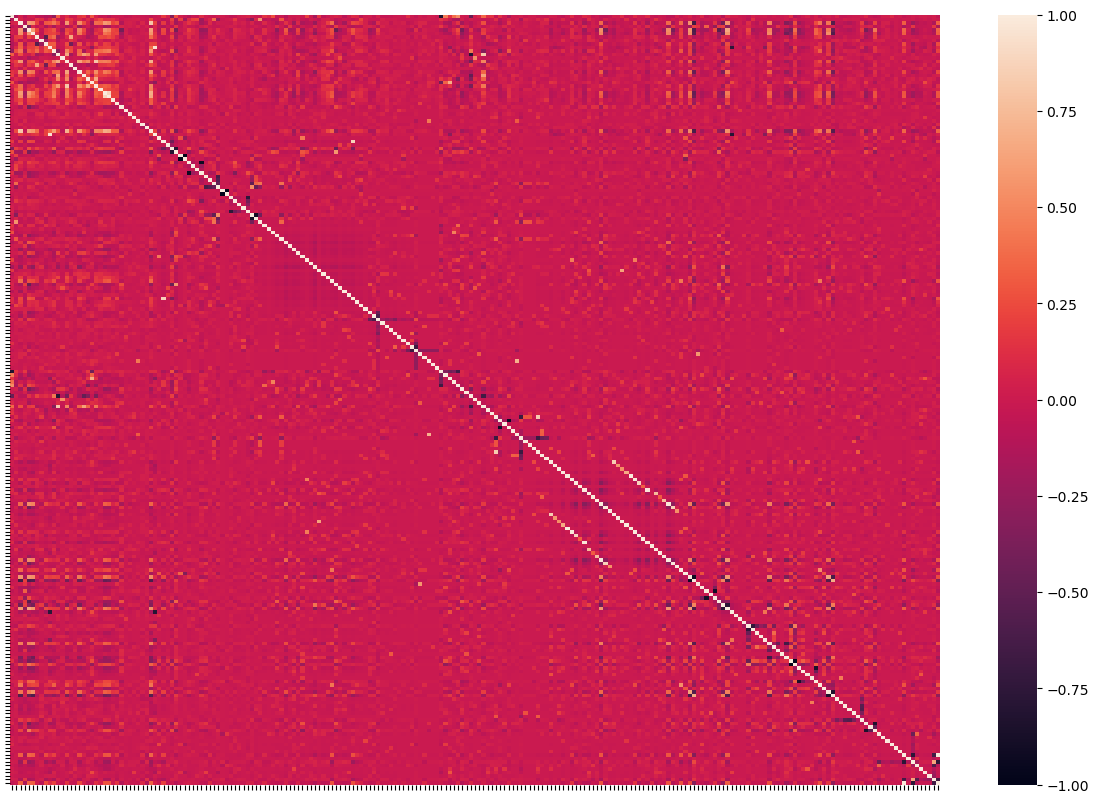

In [7]:
## Heatmap correlation
# calculate the correlation matrix
corr = data.corr()
# plot the heatmap
fig, ax = plt.subplots(figsize=(15,10)) 
g = sns.heatmap(corr, 
        xticklabels=corr.columns,
        yticklabels=corr.columns, ax = ax)
g.set(xticklabels=[]);
g.set(yticklabels=[]);

In [8]:
# 25% of data will be used to test. Split arrays or matrices into random train and test subsets.

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [9]:
# Standardize features by removing the mean and scaling to unit variance
scaler = StandardScaler()
x_train_std=scaler.fit_transform(x_train);
x_train_std = scaler.transform(x_train)
x_test_std = scaler.transform(x_test)

In [10]:
print('Number of variables: ', np.size(x_train,1), ' , number of obs: ', len(x_train))

Number of variables:  220  , number of obs:  1071


In [11]:
## Grid Search CV common params

# for time series see: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
# visualize what is going on: https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py
# merge the output of TimeSeriesSplit with GridSearchCV(estimator, param_grid, cv=cv, ...) to benefit from easy parallel computing
# Example (from https://stackoverflow.com/questions/46732748/how-do-i-use-a-timeseriessplit-with-a-gridsearchcv-object-to-tune-a-model-in-sci):
# from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
# import numpy as np
# X = np.array([[4, 5, 6, 1, 0, 2], [3.1, 3.5, 1.0, 2.1, 8.3, 1.1]]).T
# y = np.array([1, 6, 7, 1, 2, 3])
# param_search = {'max_depth' : [3, 5]}
# tscv = TimeSeriesSplit(n_splits=2)
# gsearch = GridSearchCV(estimator=model, cv=tscv,
#                         param_grid=param_search)
# gsearch.fit(X, y)

# Number of K-folds for models to CV and number of workers
n_folds = 5
n_jobs = -1 #Number processor used. -1= all available processor

In [12]:
%%time
# Linear
reg = LinearRegression().fit(x_train, y_train)

CPU times: user 44.8 ms, sys: 6.71 ms, total: 51.6 ms
Wall time: 41.2 ms


In [13]:
%%time
# Lasso
lasso = Lasso()
alphas = np.linspace(0.002, 0.01, 150)
parameters = {'alpha': alphas}
gs_lasso = GridSearchCV(lasso, parameters, cv=n_folds, refit=True, n_jobs=n_jobs, scoring = 'neg_mean_squared_error', verbose=2)
gs_lasso.fit(x_train_std, y_train)
gs_lasso.best_params_

Fitting 5 folds for each of 150 candidates, totalling 750 fits
CPU times: user 1.11 s, sys: 229 ms, total: 1.34 s
Wall time: 15 s


{'alpha': 0.004577181208053692}

In [14]:
%%time
# Ridge
ridge = Ridge()
alphas_ridge = np.linspace(1, 300, 150)
parameters = {'alpha': alphas_ridge}
gs_ridge = GridSearchCV(ridge, parameters, cv=n_folds, refit=True, n_jobs=n_jobs, scoring = 'neg_mean_squared_error', verbose=2)
gs_ridge.fit(x_train_std, y_train)
gs_ridge.best_params_

Fitting 5 folds for each of 150 candidates, totalling 750 fits
[CV] END ........................................alpha=0.002; total time=   0.1s
[CV] END .........................alpha=0.002053691275167785; total time=   0.1s
[CV] END ........................alpha=0.0021073825503355706; total time=   0.1s
[CV] END ........................alpha=0.0021073825503355706; total time=   0.1s
[CV] END ........................alpha=0.0021610738255033557; total time=   0.2s
[CV] END .........................alpha=0.002214765100671141; total time=   0.1s
[CV] END ........................alpha=0.0022684563758389262; total time=   0.1s
[CV] END ........................alpha=0.0022684563758389262; total time=   0.1s
[CV] END ........................alpha=0.0023221476510067113; total time=   0.1s
[CV] END .........................alpha=0.002375838926174497; total time=   0.0s
[CV] END .........................alpha=0.002375838926174497; total time=   0.1s
[CV] END .........................alpha=0.0024

{'alpha': 179.59731543624162}

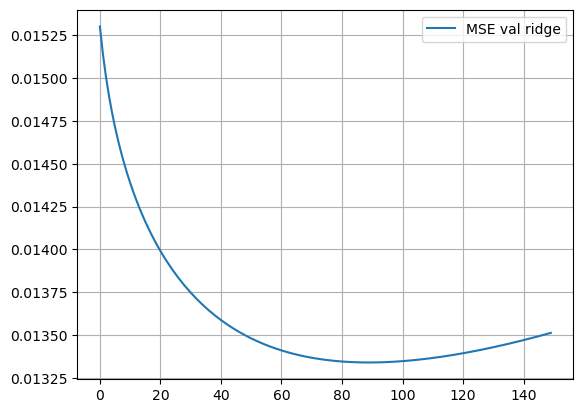

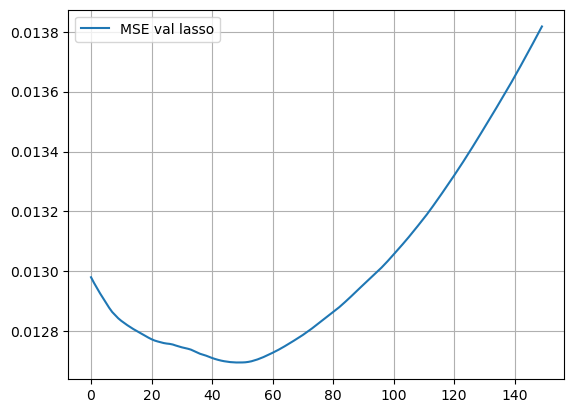

In [15]:
# Plot CV scores lasso and ridge
Df_val = pd.DataFrame(np.matrix([-gs_ridge.cv_results_['mean_test_score']]).T, columns = ["MSE val ridge"])
Df_val.set_axis(alphas_ridge, axis=0)
Df_val.plot()
plt.grid(True)
plt.show()
Df_val = pd.DataFrame(np.matrix([-gs_lasso.cv_results_['mean_test_score']]).T, columns = ["MSE val lasso"])
Df_val.set_axis(alphas, axis=0)
Df_val.plot()
plt.grid(True)
plt.show()

In [16]:
# Print number of coefficients !=0 Lasso 
print("Number of variables selected by Lasso: ", np.sum(gs_lasso.best_estimator_.coef_!=0), "(", np.round(np.sum(gs_lasso.best_estimator_.coef_!=0)/np.size(gs_lasso.best_estimator_.coef_)*100,2),"%)")

Number of variables selected by Lasso:  76 ( 34.55 %)


OLS
test 
RMSE
0.13188330607848794
train 
RMSE
0.08656323960377489


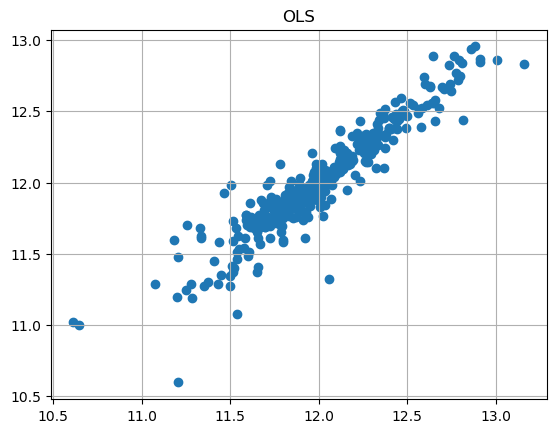

In [17]:
print("OLS")
print('test \nRMSE')
print(np.sqrt(mean_squared_error(reg.predict(x_test), y_test)))
print('train \nRMSE')
print(np.sqrt(mean_squared_error(reg.predict(x_train), y_train)))
plt.scatter(reg.predict(x_test), y_test)
plt.grid();
plt.title("OLS");

Lasso
test 
RMSE
0.12173186193361027
train and val 
RMSE
0.09853301280856222 0.11267669858861118


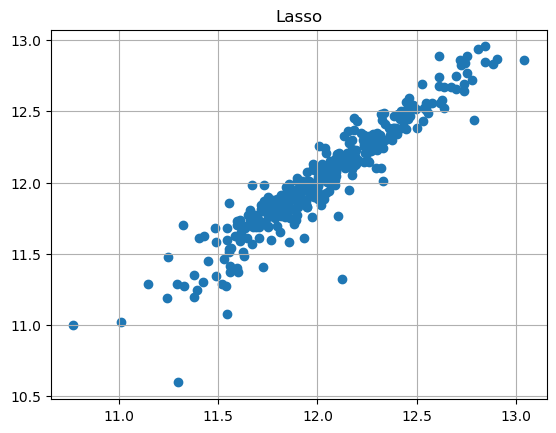

In [18]:
print("Lasso")
print('test \nRMSE')
print(np.sqrt(mean_squared_error(gs_lasso.predict(x_test_std), y_test)))
print('train and val \nRMSE')
print(np.sqrt(mean_squared_error(gs_lasso.predict(x_train_std), y_train)), np.sqrt(-gs_lasso.best_score_))
plt.scatter(gs_lasso.predict(x_test_std), y_test)
plt.grid();
plt.title("Lasso");

Ridge
test 
RMSE
0.12519162858077276
train and val 
RMSE
0.0919553496652098 0.11549531251507063


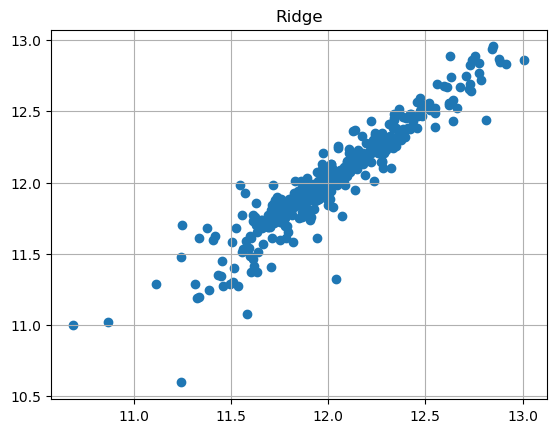

[CV] END ............................alpha=21.06711409395973; total time=   0.0s
[CV] END ............................alpha=21.06711409395973; total time=   0.0s
[CV] END ...........................alpha=23.073825503355707; total time=   0.0s
[CV] END ............................alpha=33.10738255033557; total time=   0.0s
[CV] END ............................alpha=33.10738255033557; total time=   0.0s
[CV] END ............................alpha=33.10738255033557; total time=   0.0s
[CV] END ............................alpha=33.10738255033557; total time=   0.0s
[CV] END ............................alpha=33.10738255033557; total time=   0.0s
[CV] END ............................alpha=35.11409395973155; total time=   0.0s
[CV] END ............................alpha=35.11409395973155; total time=   0.0s
[CV] END ............................alpha=35.11409395973155; total time=   0.0s
[CV] END ............................alpha=39.12751677852349; total time=   0.0s
[CV] END ...................

In [19]:
print("Ridge")
print('test \nRMSE')
print(np.sqrt(mean_squared_error(gs_ridge.predict(x_test_std), y_test)))
print('train and val \nRMSE')
print(np.sqrt(mean_squared_error(gs_ridge.predict(x_train_std), y_train)), np.sqrt(-gs_ridge.best_score_))
plt.scatter(gs_ridge.predict(x_test_std), y_test)
plt.grid();
plt.title("Ridge");